In [1]:
# function to calculate the autopet3_py metrics 

# Method to get the lesion metrics and save as a csv

In [2]:

import os
import glob
import json
import pickle

import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk

import numpy as np
import nibabel as nib
import pathlib as plb
import csv
import sys

import argparse

def handle_arguments():
    """
    Handle command line arguments for processing images.
    """
    parser = argparse.ArgumentParser(description='Process probability analysis with various options')
    parser.add_argument('-k', '--key', type=str, default='*', 
                       help='Key pattern for file matching (default: *)')
    parser.add_argument('-l', '--lesion-only', action='store_true', 
                       help='Process only lesion data, skip CTImage object creation')
    parser.add_argument('-f', '--fold', type=str, default='comb', 
                       help='Fold name/number (default: 1)')
    parser.add_argument('-s', '--skip-existing', action='store_true',
                       help='Skip processing files that have already been processed', default=False)
    parser.add_argument('-i', '--image-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/imagesTr/", help='Directory containing images (default: ../imagesTr/)')
    parser.add_argument('-m', '--mets-only', action='store_true', 
                       help='Process only mets data, skip lesion-only data')
    parser.add_argument('-ld', '--label-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/", help='Directory containing labels (default: ../labelsTr/)') 
    parser.add_argument('-b', '--bone-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/Biratal/bone-metastasis/totalsegmentator/bone_segmentations_fold1/", help='Directory containing bone segmentations (default: ../totalsegmentator/bone_segmentations_fold1/)')

    parser.add_argument('-p', '--pred-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/test_predictions/", 
                        help='Directory containing prediction files (default: //dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/test_predictions/)')

    parser.add_argument('-u', '--uncertainty-dir', type=str, default="//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/uncertainty_maps/", 
                        help='Directory containing uncertainty maps (default: //dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset888_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1_ens_comb/uncertainty_maps/)')
    parser.add_argument('-o', '--save-dir', type=str, default=args.pred_dir, 
                        help='Directory to save lesion analysis results (default: ./lesion_analysis_fold)')
    args = parser.parse_args()
    return args


def nii2numpy(nii_path):
    # input: path of NIfTI segmentation file, output: corresponding numpy array and voxel_vol in ml
    mask_nii = nib.load(str(nii_path))
    mask = mask_nii.get_fdata()
    pixdim = mask_nii.header['pixdim']   
    voxel_vol = pixdim[1]*pixdim[2]*pixdim[3]/1000
    return mask, voxel_vol


def con_comp(seg_array):
    # input: a binary segmentation array output: an array with seperated (indexed) connected components of the segmentation array
    connectivity = 18
    conn_comp = cc3d.connected_components(seg_array, connectivity=connectivity)
    return conn_comp



def false_pos_pix(gt_array,pred_array):
    # compute number of voxels of false positive connected components in prediction mask
    pred_conn_comp = con_comp(pred_array)
    
    false_pos = 0
    false_detected_lesion_count = 0
    
    for idx in range(1,pred_conn_comp.max()+1):
        comp_mask = np.isin(pred_conn_comp, idx)
        if (comp_mask*gt_array).sum() == 0:
            false_pos = false_pos+comp_mask.sum()
            false_detected_lesion_count += 1
    return false_pos, false_detected_lesion_count, pred_conn_comp.max()

def false_neg_pix(gt_array,pred_array):
    # compute number of voxels of false negative connected components (of the ground truth mask) in the prediction mask
    gt_conn_comp = con_comp(gt_array)
    
    false_neg = 0
    false_missed_lesion_count = 0
    
    for idx in range(1,gt_conn_comp.max()+1):
        comp_mask = np.isin(gt_conn_comp, idx)
        if (comp_mask*pred_array).sum() == 0:
            false_neg = false_neg+comp_mask.sum()
            false_missed_lesion_count += 1
            
    return false_neg, false_missed_lesion_count, gt_conn_comp.max()

def dice_score(mask1,mask2):
    # compute foreground Dice coefficient
    overlap = (mask1*mask2).sum()
    sum = mask1.sum()+mask2.sum()
    dice_score = 2*overlap/sum
    return dice_score



def compute_metrics(nii_gt_path, nii_pred_path):
    # main function
    gt_array, voxel_vol = nii2numpy(nii_gt_path)
    pred_array, voxel_vol = nii2numpy(nii_pred_path)
    false_neg_vol, false_missed_lesion_count, gt_lesion_count= false_neg_pix(gt_array, pred_array)
    false_neg_vol = false_neg_vol*voxel_vol

    false_pos_vol, false_detected_lesion_count, pred_lesion_count = false_pos_pix(gt_array, pred_array)
    false_pos_vol = false_pos_vol*voxel_vol
    
    dice_sc = dice_score(gt_array,pred_array)

    return dice_sc, false_pos_vol, false_neg_vol, false_missed_lesion_count, false_detected_lesion_count

def convert_location_to_case_name(file_locations):
    case_names = []
    for path in file_locations:
        parts = path.split('/')
        # Extract patient ID from PETCT_xxxx
        patient_folder = parts[2]  # e.g., 'PETCT_0011f3deaf'
        patient_id = patient_folder.replace('PETCT_', '')
        
        # Extract scan folder (date-NA-scan_type-number)
        scan_folder = parts[3]  # e.g., '03-23-2003-NA-PET-CT Ganzkoerper...-10445'
        
        # Create CSV filename
        case_name = f"fdg_{patient_id}_{scan_folder}"
        case_names.append(case_name)
    
    return np.array(case_names)

def read_summary_file(path, fold, validation): 
    import json
    with open(path.format(fold=fold, validation=validation), "r") as f:
        return json.load(f)


In [3]:
import tqdm
# set up paths and parameters
os.environ['nnUNet_results'] = "../../nnUNet_results/"

DEFAULT_SUMMARY_PATH = "{nnUNet_results}/{input_dataset}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{validation}/summary.json"\
    .format(nnUNet_results=os.environ['nnUNet_results'], input_dataset="{input_dataset}", fold="{fold}", validation="{validation}") 
    
print(DEFAULT_SUMMARY_PATH)

nnUNet_results = os.environ['nnUNet_results']
dataset_name = "Dataset222_AutoPet"
fold = "fold_11"
testing_split = "validation_279"

pred_dir="{nnUNet_results}/{dataset_name}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{testing_split}"
gt_dir = "{nnUNet_results}/test/gt/"

out_dir="{nnUNet_results}/{dataset_name}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{testing_split}/lesion_metrics.csv"


../../nnUNet_results//{input_dataset}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{validation}/summary.json


In [4]:
prediction_file_names = [x for x in os.listdir(pred_dir.format(nnUNet_results=nnUNet_results,
 dataset_name=dataset_name, 
 fold=fold, 
 testing_split=testing_split)) if x.endswith('.nii.gz')]

gt_files = [os.path.join(gt_dir.format(nnUNet_results=nnUNet_results), x) for x in prediction_file_names]  # Match GT files to prediction files based on filename
prediction_files = [os.path.join(pred_dir.format(nnUNet_results=nnUNet_results,
 dataset_name=dataset_name,
 fold=fold,
 testing_split=testing_split), x) for x in prediction_file_names]
 

In [5]:
path = DEFAULT_SUMMARY_PATH.format(
    input_dataset=f"Dataset999_AutoPet",
    fold="fold_11",
    validation="validation_279"
)

temp_json = read_summary_file(path, fold="fold_11", validation="validation_279")
temp_test_json = read_summary_file(path, fold="fold_11", validation="test_predictions")

non_diseased_cases = []

for case in temp_json['metric_per_case']: 
    if case['metrics']['1']['TP'] + case['metrics']['1']['FN'] == 0: 
        non_diseased_cases.append(os.path.basename(case['prediction_file']).replace('.nii.gz', ''))


for case in temp_test_json['metric_per_case']: 
    if case['metrics']['1']['TP'] + case['metrics']['1']['FN'] == 0: 
        non_diseased_cases.append(os.path.basename(case['prediction_file']).replace('.nii.gz', ''))




## Once you have the lesion metrics, processing to generate the tables 
This is to generate the figures for the validation table figures. So the Dice, FP Vol, FN Vol across disease 

In [ ]:
def load_dataset_folds_with_diagnosis(
    dataset_num, 
    folds=[f'fold_{i}' for i in range(0, 11)], 
    validation="validation_279"
):
    path = DEFAULT_SUMMARY_PATH.format(
        input_dataset=f"Dataset{dataset_num}_AutoPet",
        fold="{fold}",
        validation="{validation}"
    )
    fdg_case_count = [6, 33, 66, 72, 99, 132, 199, 265, 332, 398, 464, 664]
    psma_case_count = [3, 18, 37, 40, 55, 75, 113, 151, 189, 227, 265, 379]


    # Load FDG metadata once upfront
    fdg_metadata = pd.read_csv('fdg_metadata.csv')
    fdg_metadata['file'] = convert_location_to_case_name(fdg_metadata['File Location'].values)
    fdg_metadata = fdg_metadata[['file', 'diagnosis']].drop_duplicates(subset=['file', 'diagnosis'])

    def get_diagnosis(case_name):
        """Look up diagnosis from metadata, falling back to PROSTATE_CANCER for PSMA."""
        if case_name.lower().startswith('psma'):
            return 'PROSTATE_CANCER'
        match = fdg_metadata[fdg_metadata['file'] == case_name]
        if not match.empty:
            return match['diagnosis'].values[0]
        return None



    summary_dfs = []
    # Store individual rows across all folds, we'll aggregate at the end
    all_rows = []

    for fold in folds:
        filepath = path.format(fold=fold, validation=validation)
        try:
            fold_data = read_summary_file(path, fold=fold, validation=validation)

            lesion_metrics_path = filepath.replace("summary.json", "lesion_metrics.csv")
            lesion_metrics_df = pd.read_csv(lesion_metrics_path)
            # Strip extension once
            lesion_metrics_df['filename'] = lesion_metrics_df['filename'].str.replace('.nii.gz', '', regex=False)
                        
            for case in fold_data['metric_per_case']:
                metrics = case['metrics']['1']
                pred_file = case['prediction_file']
                case_name = os.path.basename(pred_file).replace('.nii.gz', '')

                lesion_subdf = lesion_metrics_df[lesion_metrics_df['filename'] == case_name]
                # if the metrics TP + FN is 0 then false_neg_vol is 0 too 
                if metrics['TP'] + metrics['FN'] == 0:
                    lesion_subdf['false_neg_vol'] = np.nan

                tracer = None
                if case_name.lower().startswith('fdg'):
                    tracer = 'FDG'
                elif case_name.lower().startswith('psma'):
                    tracer = 'PSMA'

                diagnosis = get_diagnosis(case_name)

                all_rows.append({
                    "fold":      fold,
                    "fold_num":  int(fold.split('_')[1]),
                    "case_name": case_name,
                    "tracer":    tracer,
                    "diagnosis": diagnosis,
                    "Dice":      metrics['Dice'],
                    "false_pos_vol":        lesion_subdf['false_pos_vol'].values[0] if not lesion_subdf.empty else np.nan,
                    "false_neg_vol":        lesion_subdf['false_neg_vol'].values[0] if not lesion_subdf.empty else np.nan,
                })

            fold_rows = [r for r in all_rows if r['fold'] == fold]
            fold_df = pd.DataFrame(fold_rows)

            summary_dfs.append(pd.DataFrame({
                "fold":        [str(fold)],
                "fold_num":    [int(fold.split('_')[1])],
                "Dice":        [round(fold_data['foreground_mean']['Dice'], 4)],
                "false_pos_vol": [round(fold_df['false_pos_vol'].mean(), 2)],
                "false_neg_vol": [round(fold_df['false_neg_vol'].mean(), 2)],
                "n_cases":     [len(fold_data['metric_per_case'])],
            }))
        except Exception as e:
            print(f"Could not read fold {fold} for dataset {dataset_num}")
            print(f"Expected path: {filepath}")
            print(f"Error: {e}")

    # Build a flat dataframe of all cases
    all_cases_df = pd.DataFrame(all_rows)

    if '999' not in path: 
        print("Baseline")
        all_cases_df['num_cases'] = all_cases_df.apply(lambda row: fdg_case_count[row['fold_num'] + 2] if row['tracer'] == 'FDG' else (psma_case_count[row['fold_num'] + 2] if row['tracer'] == 'PSMA' else np.nan), axis=1)
    else: 
        all_cases_df['num_cases'] = all_cases_df.apply(lambda row: fdg_case_count[row['fold_num']] if row['tracer'] == 'FDG' else (psma_case_count[row['fold_num']] if row['tracer'] == 'PSMA' else np.nan), axis=1)
   
    all_cases_df['diseased'] = all_cases_df['diagnosis'] != 'NEGATIVE'
    all_cases_df['diseased'] = all_cases_df.apply(lambda row: False if (row['case_name'] in non_diseased_cases) else row['diseased'], axis=1)
    all_cases_df['diagnosis'] = all_cases_df.apply(lambda row: 'NEGATIVE' if row['case_name'] in non_diseased_cases else row['diagnosis'], axis=1)


    def make_summary_table(df, group_col):

        """Aggregate metrics grouped by fold + some grouping column (tracer or diagnosis)."""
        return (

            df.groupby(['fold_num', group_col])
            .agg(
                Dice=('Dice', 'mean'),
                false_pos_vol=('false_pos_vol', 'mean'),
                false_neg_vol=('false_neg_vol', 'mean'),
                n_cases=('case_name', 'count'),
            )
            .round({'Dice': 4, 'false_pos_vol': 0, 'false_neg_vol': 0})
            .reset_index()
            .rename(columns={'false_pos_vol': 'FP (ml)', 'false_neg_vol': 'FN (ml)'})
            .sort_values(['fold_num', group_col])
        )

    summary_df   = pd.concat(summary_dfs, ignore_index=True).sort_values('fold_num')
    tracer_df    = make_summary_table(all_cases_df, 'tracer')
    diagnosis_df = make_summary_table(all_cases_df, 'diagnosis')




    return summary_df, tracer_df, diagnosis_df, all_cases_df



summary, tracer, diagnosis, all_cases = load_dataset_folds_with_diagnosis(dataset_num=111, folds=[f'fold_{i}' for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], 
validation="validation_279")

summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=999, folds=[f'fold_{i}' for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]], validation="test_predictions")
summary_baseline

Baseline
Could not read fold fold_8 for dataset 999
Expected path: ../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_8/test_predictions/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_8/test_predictions/summary.json'
Could not read fold fold_12 for dataset 999
Expected path: ../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_12/test_predictions/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_12/test_predictions/summary.json'


,fold,fold_num,Dice,false_pos_vol,false_neg_vol,n_cases
0,fold_0,0,0.3151,4.27,42.34,321
1,fold_1,1,0.5368,6.46,18.12,321
2,fold_2,2,0.5858,7.35,17.40,321
3,fold_3,3,0.5812,6.43,13.32,321
4,fold_4,4,0.5934,7.49,17.71,321
5,fold_5,5,0.6112,8.92,11.59,321
6,fold_6,6,0.6233,6.85,13.46,321
7,fold_7,7,0.6012,13.69,6.85,321
8,fold_9,9,0.6362,9.35,9.01,321
9,fold_10,10,0.6411,7.31,11.43,321


In [7]:
summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=330, folds=[f'fold_{i}' for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]], validation="validation_279")
print(summary_baseline['false_neg_vol'][:5].mean().round(2), end = " +/- ")
print(summary_baseline['false_neg_vol'][:5].std().round(2))

print(summary_baseline['false_pos_vol'][:5].mean().round(2), end = " +/- ")
print(summary_baseline['false_pos_vol'][:5].std().round(2))

summary_baseline


Could not read fold fold_6 for dataset 330
Expected path: ../../nnUNet_results//Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_6/validation_279/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_6/validation_279/summary.json'
Could not read fold fold_7 for dataset 330
Expected path: ../../nnUNet_results//Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_7/validation_279/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_7/validation_279/summary.json'
Could not read fold fold_8 for dataset 330
Expected path: ../../nnUNet_results//Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_8/validation_279/summary.json
Error: [Errno 2] No such file or d

,fold,fold_num,Dice,false_pos_vol,false_neg_vol,n_cases
0,fold_0,0,0.6295,16.21,12.33,247
1,fold_1,1,0.6412,19.03,13.03,247
2,fold_2,2,0.6574,18.14,12.13,247
3,fold_3,3,0.6360,20.69,13.44,247
4,fold_4,4,0.6309,17.56,22.01,247
5,fold_5,5,0.6450,18.98,11.25,247


In [8]:
np.std([12.33, 13.03, 12.13, 13.44, 22.01], ddof=1).round(2)

np.float64(4.18)

In [9]:
summary_baseline, _, _, all_cases_baseline = load_dataset_folds_with_diagnosis(dataset_num=999, folds=[f'fold_{i}' for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]], validation="test_predictions")
summary_baseline

Could not read fold fold_8 for dataset 999
Expected path: ../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_8/test_predictions/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_8/test_predictions/summary.json'
Could not read fold fold_12 for dataset 999
Expected path: ../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_12/test_predictions/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_12/test_predictions/summary.json'


,fold,fold_num,Dice,false_pos_vol,false_neg_vol,n_cases
0,fold_0,0,0.3151,4.27,42.34,321
1,fold_1,1,0.5368,6.46,18.12,321
2,fold_2,2,0.5858,7.35,17.40,321
3,fold_3,3,0.5812,6.43,13.32,321
4,fold_4,4,0.5934,7.49,17.71,321
5,fold_5,5,0.6112,8.92,11.59,321
6,fold_6,6,0.6233,6.85,13.46,321
7,fold_7,7,0.6012,13.69,6.85,321
8,fold_9,9,0.6362,9.35,9.01,321
9,fold_10,10,0.6411,7.31,11.43,321


In [10]:
"""
Paired comparison: randomized baseline folds vs FEEDS (active learning).

Assumes a per-case long dataframe like `all_cases_baseline` with columns:
    fold, fold_num, case_name, tracer, diagnosis,
    Dice, false_pos_vol, false_neg_vol, num_cases, diseased

and an equivalent FEEDS frame (`all_cases_feeds`) with the SAME case_name set,
so cases can be paired one-to-one.

What it does
------------
1. Builds the per-case "random average" by averaging across the random folds
   for each case_name (this is the apples-to-apples partner for FEEDS).
2. For each metric, runs a PAIRED t-test (what you asked for) AND a Wilcoxon
   signed-rank (robust fallback, recommended for the skewed volume metrics).
3. Reports the mean difference and a bootstrap 95% CI on that difference.

Directionality
--------------
- Dice: higher is better  -> H1 is FEEDS > random
- false_pos_vol / false_neg_vol: lower is better -> H1 is FEEDS < random
The script sets the one-sided alternative accordingly. Decide direction BEFORE
looking at results (you already have: FEEDS should help, esp. on FN).
"""

import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon

# ----------------------------------------------------------------------
# 0. Load. Replace these two lines with however you load your frames.
#    Both must have a `case_name` column and the metric columns.
# ----------------------------------------------------------------------
# all_cases_baseline = pd.read_csv("baseline.csv")
# all_cases_feeds    = pd.read_csv("feeds.csv")

METRICS = {
    "Dice":          "greater",  # FEEDS expected higher
    "false_pos_vol": "less",     # FEEDS expected lower
    "false_neg_vol": "less",     # FEEDS expected lower
}

RAND_FOLD_VALUES = None  # e.g. ["fold_0","fold_1","fold_2","fold_3","fold_4"]
                         # leave None to average over ALL folds present in baseline


def per_case_random_average(baseline: pd.DataFrame) -> pd.DataFrame:
    """Collapse the random folds to one value per case (mean across folds)."""
    df = baseline.copy()
    if RAND_FOLD_VALUES is not None:
        df = df[df["fold"].isin(RAND_FOLD_VALUES)]
    agg = (df.groupby("case_name")[list(METRICS)]
             .mean()
             .reset_index())
    return agg


def bootstrap_ci(diff: np.ndarray, n_boot: int = 10000, seed: int = 0):
    """95% percentile bootstrap CI on the mean of paired differences."""
    rng = np.random.default_rng(seed)
    diff = diff[~np.isnan(diff)]
    boot = np.array([rng.choice(diff, diff.size, replace=True).mean()
                     for _ in range(n_boot)])
    return np.percentile(boot, [2.5, 97.5])


def run(baseline: pd.DataFrame, feeds: pd.DataFrame) -> pd.DataFrame:
    rand = per_case_random_average(baseline)
    fe = feeds.groupby("case_name")[list(METRICS)].mean().reset_index()

    # Pair strictly on shared case_name
    merged = rand.merge(fe, on="case_name", suffixes=("_rand", "_feeds"))
    n = len(merged)
    print(f"Paired on {n} cases.\n")

    rows = []
    for metric, side in METRICS.items():
        r = merged[f"{metric}_rand"].to_numpy()
        f = merged[f"{metric}_feeds"].to_numpy()

        # Drop pairs where either is NaN (e.g. Dice is NaN on negative cases)
        mask = ~(np.isnan(r) | np.isnan(f))
        r, f = r[mask], f[mask]
        diff = f - r  # FEEDS minus random

        # Paired t-test (two-sided p, then halve appropriately for one-sided)
        t_stat, t_p_two = ttest_rel(f, r)
        # one-sided p in the hypothesised direction
        if side == "greater":
            t_p = t_p_two / 2 if t_stat > 0 else 1 - t_p_two / 2
            w_stat, w_p = wilcoxon(f, r, alternative="greater")
        else:  # "less"  (FEEDS lower is better)
            t_p = t_p_two / 2 if t_stat < 0 else 1 - t_p_two / 2
            w_stat, w_p = wilcoxon(f, r, alternative="less")

        lo, hi = bootstrap_ci(diff)

        rows.append({
            "metric": metric,
            "n_pairs": mask.sum(),
            "mean_rand": r.mean(),
            "mean_feeds": f.mean(),
            "mean_diff(feeds-rand)": diff.mean(),
            "ci95_lo": lo,
            "ci95_hi": hi,
            "t_stat": t_stat,
            "t_p_1sided": t_p,
            "wilcoxon_p_1sided": w_p,
        })

    res = pd.DataFrame(rows)
    pd.set_option("display.float_format", lambda x: f"{x:.4g}")
    print(res.to_string(index=False))
    return res


if __name__ == "__main__":
    # results = run(all_cases_baseline, all_cases_feeds)
    # results.to_csv("/mnt/user-data/outputs/feeds_stats_results.csv", index=False)
    pass

In [11]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\BhattacharyaLab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
summary, tracer, diagnosis, all_cases = load_dataset_folds_with_diagnosis(dataset_num=444, folds=[f'fold_{i}' for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], 
validation="validation_279")
summary

Could not read fold fold_0 for dataset 444
Expected path: ../../nnUNet_results//Dataset444_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset444_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json'
Could not read fold fold_5 for dataset 444
Expected path: ../../nnUNet_results//Dataset444_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_5/validation_279/summary.json
Error: [Errno 2] No such file or directory: '../../nnUNet_results//Dataset444_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_5/validation_279/summary.json'
Could not read fold fold_6 for dataset 444
Expected path: ../../nnUNet_results//Dataset444_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_6/validation_279/summary.json
Error: [Errno 2] No such file or d

,fold,fold_num,Dice,false_pos_vol,false_neg_vol,n_cases
0,fold_1,1,0.6105,16.78,23.11,247
1,fold_2,2,0.6221,18.78,22.62,247
2,fold_3,3,0.6426,19.70,13.19,247
3,fold_4,4,0.6557,17.87,17.67,247


In [13]:
# summary, tracer, diagnosis, all_cases = load_dataset_folds_with_diagnosis(dataset_num=999, folds=[f'fold_{i}' for i in [3, 5, 10, 11]], 
# validation="test_predictions")

# all_cases['num_cases'] = all_cases.apply(lambda row: fdg_case_count[row['fold_num'] + 2] if row['tracer'] == 'FDG' else (psma_case_count[row['fold_num'] + 2] if row['tracer'] == 'PSMA' else np.nan), axis=1)
# all_cases['diseased'] = all_cases['diagnosis'] != 'NEGATIVE'
# all_cases['diseased'] = all_cases.apply(lambda row: False if (row['case_name'] in non_diseased_psma) else row['diseased'], axis=1)
# all_cases['diagnosis'] = all_cases.apply(lambda row: 'NEGATIVE' if row['case_name'] in non_diseased_psma else row['diagnosis'], axis=1)
# summary

In [14]:
# map all cases fold num to the cases_111

all_cases_baseline = all_cases_baseline[all_cases_baseline['fold_num'] > 1]
alc_grouped_base = all_cases_baseline.groupby(['diseased', 'tracer', 'fold_num', 'num_cases']).agg({'Dice': 'mean', 'false_pos_vol': 'mean', 'false_neg_vol': 'mean', 'case_name': 'count'}).round(3)
alc_grouped = all_cases.groupby(['diseased', 'tracer', 'fold_num', 'num_cases']).agg({'Dice': 'mean', 'false_pos_vol': 'mean', 'false_neg_vol': 'mean', 'case_name': 'count'}).round(3)
# do a difference map between the two datasets to see if there's any improvement in the metrics

all_cases_diff = all_cases_baseline.merge(all_cases, on=['case_name', 'num_cases', 'tracer', 'diagnosis', 'diseased'], suffixes=('_baseline', '_new'))
all_cases_diff['Dice_diff'] = all_cases_diff['Dice_new'] - all_cases_diff['Dice_baseline']
all_cases_diff['false_pos_vol_diff'] = all_cases_diff['false_pos_vol_new'] - all_cases_diff['false_pos_vol_baseline']
all_cases_diff['false_neg_vol_diff'] = all_cases_diff['false_neg_vol_new'] - all_cases_diff['false_neg_vol_baseline']

# now do the groupby 
all_cases_diff_grouped = all_cases_diff.groupby(['diseased', 'tracer', 'num_cases']).agg({'Dice_diff': 'mean', 'false_pos_vol_diff': 'mean', 'false_neg_vol_diff': 'mean', 'case_name': 'count'}).round(3)
all_cases_diff_grouped

,,,Dice_diff,false_pos_vol_diff,false_neg_vol_diff,case_name
diseased,tracer,num_cases,,,,


In [15]:
import pingouin as pg
from scipy import stats
import numpy as np
import pandas as pd

df = all_cases_diff_agg.copy()
df = df.dropna(subset=['Dice_baseline', 'Dice_new'])
df['dice_diff'] = df['Dice_new'] - df['Dice_baseline']

# drop the endpoint folds where baseline == new (no comparison possible)
df = df[df['dice_diff'].abs() > 1e-9]

print("Pooled Wilcoxon (across all num_cases) — Dice, two-sided AND one-sided (new > baseline)")
print("=" * 110)
print(f"{'subgroup':<25} {'n':>5} {'mean_diff':>10} {'median_diff':>12} "
      f"{'win_rate':>9} {'p_two-sided':>13} {'p_AL>base':>11}")
print("-" * 110)

subgroups = {
    'Overall':            df,
    'FDG':                df[df['tracer'] == 'FDG'],
    'PSMA':               df[df['tracer'] == 'PSMA'],
    'FDG / Diseased':     df[(df['tracer'] == 'FDG')  & (df['diseased'])],
    'FDG / Non-diseased': df[(df['tracer'] == 'FDG')  & (~df['diseased'])],
    'PSMA / Diseased':    df[(df['tracer'] == 'PSMA') & (df['diseased'])],
    'PSMA / Non-diseased':df[(df['tracer'] == 'PSMA') & (~df['diseased'])],
    'Diseased (all)':     df[df['diseased']],
    'Non-diseased (all)': df[~df['diseased']],
}

for name, sub in subgroups.items():
    diffs = sub['dice_diff'].values
    n = len(diffs)
    if n < 3:
        print(f"{name:<25} {n:>5}  (insufficient data)")
        continue
    mean_d   = float(np.mean(diffs))
    median_d = float(np.median(diffs))
    win_rate = float(np.mean(diffs > 0))
    _, p_two = stats.wilcoxon(diffs, alternative='two-sided')
    _, p_one = stats.wilcoxon(diffs, alternative='greater')  # AL > baseline
    print(f"{name:<25} {n:>5} {mean_d:>10.4f} {median_d:>12.4f} "
          f"{win_rate:>8.1%} {p_two:>13.4f} {p_one:>11.4f}")

ModuleNotFoundError: No module named 'pingouin'

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

df = all_cases_diff_agg.copy()

for metric, better in [('false_pos_vol', 'lower'), ('false_neg_vol', 'lower')]:
    print(f"\n{'='*100}")
    print(f"Pooled Wilcoxon — {metric} (lower is better, so 'AL improves' = AL < baseline)")
    print(f"{'='*100}")
    print(f"{'subgroup':<25} {'n':>5} {'mean_diff':>12} {'median_diff':>13} "
          f"{'win_rate':>10} {'p_two-sided':>13} {'p_AL<base':>11}")
    print("-" * 100)

    sub_df = df.dropna(subset=[f'{metric}_baseline', f'{metric}_new']).copy()
    sub_df['diff'] = sub_df[f'{metric}_new'] - sub_df[f'{metric}_baseline']
    sub_df = sub_df[sub_df['diff'].abs() > 1e-9]

    subgroups = {
        'Overall':              sub_df,
        'FDG':                  sub_df[sub_df['tracer'] == 'FDG'],
        'PSMA':                 sub_df[sub_df['tracer'] == 'PSMA'],
        'FDG / Diseased':       sub_df[(sub_df['tracer'] == 'FDG')  & sub_df['diseased']],
        'FDG / Non-diseased':   sub_df[(sub_df['tracer'] == 'FDG')  & ~sub_df['diseased']],
        'PSMA / Diseased':      sub_df[(sub_df['tracer'] == 'PSMA') & sub_df['diseased']],
        'PSMA / Non-diseased':  sub_df[(sub_df['tracer'] == 'PSMA') & ~sub_df['diseased']],
        'Diseased (all)':       sub_df[sub_df['diseased']],
        'Non-diseased (all)':   sub_df[~sub_df['diseased']],
    }

    for name, s in subgroups.items():
        diffs = s['diff'].values
        n = len(diffs)
        if n < 3:
            print(f"{name:<25} {n:>5}  (insufficient data)")
            continue
        # win = AL has LOWER value (since lower is better)
        win_rate = float(np.mean(diffs < 0))
        _, p_two = stats.wilcoxon(diffs, alternative='two-sided')
        _, p_one = stats.wilcoxon(diffs, alternative='less')  # AL < baseline
        print(f"{name:<25} {n:>5} {float(np.mean(diffs)):>12.3f} {float(np.median(diffs)):>13.3f} "
              f"{win_rate:>9.1%} {p_two:>13.4f} {p_one:>11.4f}")


Pooled Wilcoxon — false_pos_vol (lower is better, so 'AL improves' = AL < baseline)
subgroup                      n    mean_diff   median_diff   win_rate   p_two-sided   p_AL<base
----------------------------------------------------------------------------------------------------
Overall                    1653        0.660        -0.066     53.5%        0.0001      0.0000
FDG                        1042       -0.032        -0.149     57.0%        0.0000      0.0000
PSMA                        611        1.839         0.049     47.6%        0.0370      0.9815
FDG / Diseased              542       -1.206        -0.056     52.8%        0.0005      0.0002
FDG / Non-diseased          500        1.241        -0.255     61.6%        0.0000      0.0000
PSMA / Diseased             527        2.037         0.066     46.9%        0.0100      0.9950
PSMA / Non-diseased          84        0.595        -0.065     52.4%        0.4286      0.2143
Diseased (all)             1069        0.393         

In [ ]:
import numpy as np
import pandas as pd

# distribution of FP changes in non-diseased cases, by tracer
df = all_cases_diff_agg.dropna(subset=['false_pos_vol_baseline', 'false_pos_vol_new']).copy()
df['fp_diff'] = df['false_pos_vol_new'] - df['false_pos_vol_baseline']
nd = df[~df['diseased']]

print("FP diff distribution in NON-DISEASED cases:")
print(nd.groupby('tracer')['fp_diff'].describe(percentiles=[.1, .25, .5, .75, .9]))

print("\nAre 'non-diseased' PSMA cases actually structured differently?")
print(nd.groupby('tracer').agg(
    n_cases=('case_name', 'nunique'),
    n_rows=('case_name', 'count'),
    fp_base_mean=('false_pos_vol_baseline', 'mean'),
    fp_new_mean=('false_pos_vol_new', 'mean'),
))

FP diff distribution in NON-DISEASED cases:
        count      mean        std         min       10%       25%  50%  \
tracer                                                                    
FDG     696.0  0.891481  50.329057 -163.885575 -8.721156 -1.293866  0.0   
PSMA    113.0  0.442135  14.423798  -65.356509 -1.487722 -0.757924  0.0   

             75%       90%         max  
tracer                                  
FDG     0.087087  2.058989  720.596400  
PSMA    0.265407  1.399848  108.899864  

Are 'non-diseased' PSMA cases actually structured differently?
        n_cases  n_rows  fp_base_mean  fp_new_mean
tracer                                            
FDG          74     696     36.805368    37.696849
PSMA         12     113     43.612122    44.054257


In [ ]:
from scipy import stats
import numpy as np

df = all_cases_diff_agg.copy()

def pooled_test(sub, metric, alt_lower_is_better=True):
    a = sub[f'{metric}_baseline'].values.astype(float)
    b = sub[f'{metric}_new'].values.astype(float)
    mask = ~(np.isnan(a) | np.isnan(b))
    diff = (b - a)[mask]
    diff = diff[np.abs(diff) > 1e-9]
    if len(diff) < 5:
        return None
    win_rate = float(np.mean(diff < 0)) if alt_lower_is_better else float(np.mean(diff > 0))
    alt = 'less' if alt_lower_is_better else 'greater'
    _, p_one = stats.wilcoxon(diff, alternative=alt)
    return dict(
        n=len(diff),
        win_pct=win_rate * 100,
        median_diff=float(np.median(diff)),
        q25=float(np.quantile(diff, 0.25)),
        q75=float(np.quantile(diff, 0.75)),
        p_one_sided=p_one,
    )

subgroups = {
    'Overall':              df,
    'FDG / Diseased':       df[(df['tracer'] == 'FDG')  & df['diseased']],
    'FDG / Non-diseased':   df[(df['tracer'] == 'FDG')  & ~df['diseased']],
    'PSMA / Diseased':      df[(df['tracer'] == 'PSMA') & df['diseased']],
    'PSMA / Non-diseased':  df[(df['tracer'] == 'PSMA') & ~df['diseased']],
}

for metric, lower_better in [('Dice', False), ('false_pos_vol', True), ('false_neg_vol', True)]:
    arrow = '↓ better' if lower_better else '↑ better'
    print(f"\n{metric} ({arrow})")
    print(f"{'subgroup':<22} {'n':>5} {'% improved':>11} {'median[IQR]':>22} {'p (1-sided)':>13}")
    print("-" * 78)
    for name, s in subgroups.items():
        res = pooled_test(s, metric, alt_lower_is_better=lower_better)
        if res is None:
            print(f"{name:<22}  (insufficient data)")
            continue
        iqr_str = f"{res['median_diff']:+.2f} [{res['q25']:+.2f},{res['q75']:+.2f}]"
        print(f"{name:<22} {res['n']:>5} {res['win_pct']:>10.1f}% {iqr_str:>22} {res['p_one_sided']:>13.4f}")


Dice (↑ better)
subgroup                   n  % improved            median[IQR]   p (1-sided)
------------------------------------------------------------------------------
Overall                 1257       51.8%    +0.00 [-0.03,+0.03]        0.0731
FDG / Diseased           615       51.7%    +0.00 [-0.02,+0.03]        0.0774
FDG / Non-diseased      (insufficient data)
PSMA / Diseased          642       51.9%    +0.00 [-0.03,+0.03]        0.2621
PSMA / Non-diseased     (insufficient data)

false_pos_vol (↓ better)
subgroup                   n  % improved            median[IQR]   p (1-sided)
------------------------------------------------------------------------------
Overall                 1653       53.5%    -0.07 [-1.23,+0.65]        0.0000
FDG / Diseased           542       52.8%    -0.06 [-1.00,+0.45]        0.0002
FDG / Non-diseased       500       61.6%    -0.26 [-3.19,+0.53]        0.0000
PSMA / Diseased          527       46.9%    +0.07 [-0.58,+1.05]        0.9950
PSMA / No

KeyError: 'median_improvement'

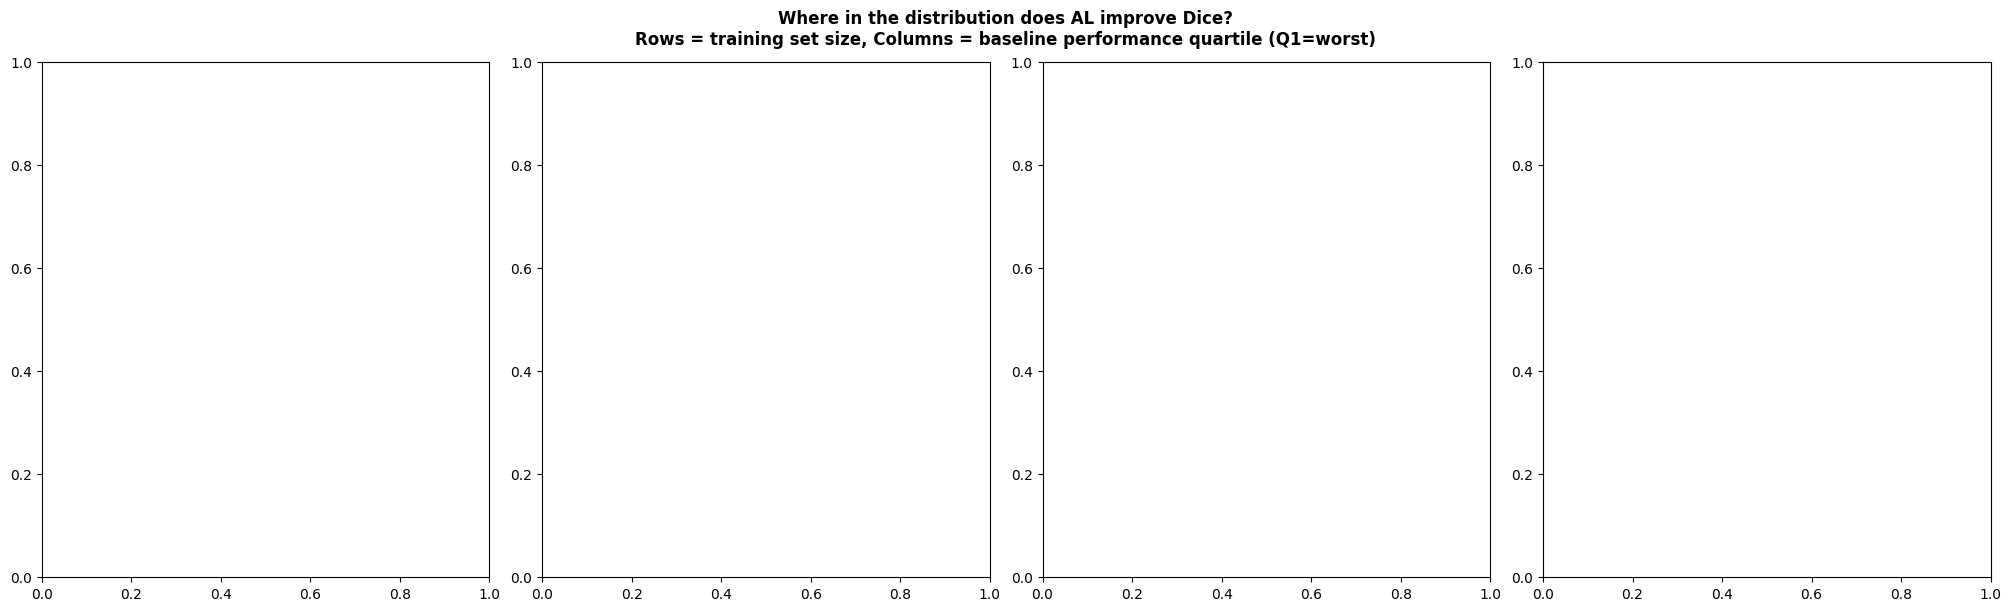

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

df = all_cases_diff_agg.copy()

# ── CONFIG ────────────────────────────────────────────────────────────────
metrics = [
    ('Dice',          False),  # higher = better, so "improvement" = positive diff
    ('false_pos_vol', True),   # lower = better, "improvement" = negative diff
    ('false_neg_vol', True),
]

subgroups = {
    'FDG / Diseased':      lambda d: d[(d['tracer'] == 'FDG')  &  d['diseased']],
    'FDG / Non-diseased':  lambda d: d[(d['tracer'] == 'FDG')  & ~d['diseased']],
    'PSMA / Diseased':     lambda d: d[(d['tracer'] == 'PSMA') &  d['diseased']],
    'PSMA / Non-diseased': lambda d: d[(d['tracer'] == 'PSMA') & ~d['diseased']],
}

N_QUARTILES = 4   # change to 5 for quintiles, 10 for deciles, etc.
QUARTILE_LABELS = ['Q1\n(worst)', 'Q2', 'Q3', 'Q4\n(best)']

# ── ANALYSIS ──────────────────────────────────────────────────────────────
def stratified_analysis(sub_df, metric, lower_is_better):
    """For each num_cases, bin cases by baseline percentile, compute diff stats per bin."""
    base_col = f'{metric}_baseline'
    new_col  = f'{metric}_new'
    out = []

    for num_cases, g in sub_df.groupby('num_cases'):
        g = g.dropna(subset=[base_col, new_col]).copy()
        if len(g) < N_QUARTILES * 2:   # need ≥2 per bin
            continue

        # rank by baseline performance. Worst quartile (Q1) = worst baseline.
        # For metrics where lower-is-better, "worst" means highest value.
        if lower_is_better:
            g['rank'] = g[base_col].rank(method='first', ascending=False)
        else:
            g['rank'] = g[base_col].rank(method='first', ascending=True)

        # split into quartiles (Q1 = worst-baseline group)
        g['quartile'] = pd.qcut(g['rank'], q=N_QUARTILES,
                                labels=range(1, N_QUARTILES + 1))

        # for "improvement", flip sign if lower_is_better so positive = improvement
        sign = -1 if lower_is_better else 1
        g['improvement'] = sign * (g[new_col] - g[base_col])

        for q, qg in g.groupby('quartile', observed=True):
            improvements = qg['improvement'].values
            improvements = improvements[~np.isnan(improvements)]
            nonzero = improvements[np.abs(improvements) > 1e-9]

            if len(nonzero) < 3:
                p = np.nan
            else:
                try:
                    _, p = stats.wilcoxon(nonzero, alternative='greater')  # AL improves
                except Exception:
                    p = np.nan

            out.append(dict(
                num_cases=num_cases,
                quartile=int(q),
                n=len(improvements),
                median_improvement=float(np.median(improvements)) if len(improvements) else np.nan,
                win_pct=100 * float(np.mean(improvements > 0)) if len(improvements) else np.nan,
                p=p,
                baseline_median=float(qg[base_col].median()),
            ))

    return pd.DataFrame(out)

# ── PLOT ──────────────────────────────────────────────────────────────────
for metric, lower_is_better in metrics:
    label = {'Dice': 'Dice', 'false_pos_vol': 'FP Volume (ml)',
             'false_neg_vol': 'FN Volume (ml)'}[metric]

    fig, axes = plt.subplots(1, len(subgroups), figsize=(5 * len(subgroups), 6),
                             constrained_layout=True)
    fig.suptitle(f'Where in the distribution does AL improve {label}?\n'
                 'Rows = training set size, Columns = baseline performance quartile (Q1=worst)',
                 fontsize=12, fontweight='bold')

    if len(subgroups) == 1:
        axes = [axes]

    # collect global vmin/vmax for consistent color scale within metric
    all_medians = []
    sg_results = {}
    for sg_name, sg_fn in subgroups.items():
        res = stratified_analysis(sg_fn(df), metric, lower_is_better)
        sg_results[sg_name] = res
        all_medians.extend(res['median_improvement'].dropna().tolist())

    if not all_medians:
        plt.close(fig)
        print(f'No data for {metric}')
        continue
    vmax = max(abs(min(all_medians)), abs(max(all_medians)))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    for ax, (sg_name, res) in zip(axes, sg_results.items()):
        if res.empty:
            ax.set_title(f'{sg_name}\n(no data)')
            ax.axis('off')
            continue

        pivot_med = res.pivot(index='num_cases', columns='quartile',
                              values='median_improvement').sort_index()
        pivot_p   = res.pivot(index='num_cases', columns='quartile', values='p').sort_index()
        pivot_win = res.pivot(index='num_cases', columns='quartile', values='win_pct').sort_index()
        pivot_n   = res.pivot(index='num_cases', columns='quartile', values='n').sort_index()

        im = ax.imshow(pivot_med.values, cmap='RdYlGn', norm=norm, aspect='auto')

        # annotate: median improvement, win%, n, significance marker
        for i, num_cases in enumerate(pivot_med.index):
            for j, q in enumerate(pivot_med.columns):
                med = pivot_med.iloc[i, j]
                p   = pivot_p.iloc[i, j]
                win = pivot_win.iloc[i, j]
                n   = pivot_n.iloc[i, j]
                if np.isnan(med):
                    continue
                sig = '*' if (not np.isnan(p) and p < 0.05) else ''
                txt = f'{med:+.3f}{sig}\n{win:.0f}% (n={int(n)})'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=7,
                        color='black' if abs(med) < vmax * 0.6 else 'white')

        ax.set_xticks(range(len(pivot_med.columns)))
        ax.set_xticklabels(QUARTILE_LABELS[:len(pivot_med.columns)], fontsize=8)
        ax.set_yticks(range(len(pivot_med.index)))
        ax.set_yticklabels([f'n={int(nc)}' for nc in pivot_med.index], fontsize=8)
        ax.set_title(sg_name, fontsize=11)
        ax.set_xlabel('Baseline performance quartile')
        if ax is axes[0]:
            ax.set_ylabel('Training set size')

    cbar = fig.colorbar(im, ax=axes, shrink=0.7, label=f'Median improvement in {label}\n(positive = AL better)')
    safe = metric.replace('_', '')
    plt.savefig(f'stratified_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()